# Révision IA : Fondamentaux du Machine Learning

Tout ce qui est à reviser pour la L3 informatique à UPEC (2026)

## Manipulation des données

### Manipulation Dataset

In [14]:
%matplotlib inline

from sklearn.datasets import load_iris

iris_dataset = load_iris()

In [15]:
print("Keys of iris_dataset:\n", iris_dataset.keys())

Keys of iris_dataset:
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [16]:
print("Type of data:", type(iris_dataset['data']))

Type of data: <class 'numpy.ndarray'>


In [17]:
print(iris_dataset['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [18]:
print("Shape of data:", iris_dataset.data.shape)

Shape of data: (150, 4)


In [19]:
print("Target names:", iris_dataset['target_names'])
print("Feature names:\n", iris_dataset['feature_names'])

Target names: ['setosa' 'versicolor' 'virginica']
Feature names:
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [20]:
print("data:\n", iris_dataset['data'][0:5])
print("target:\n", iris_dataset['target'])

data:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
target:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


### Manipulation Numpy

In [21]:
import numpy as np

x = np.array([
    [1, 2, 3], 
    [4, 5, 6]
])

In [22]:
print(x.shape)

(2, 3)


In [23]:
print("max: ", x.max())
print("min: ", x.min())

max:  6
min:  1


In [24]:
# N c'est le reste qui est egal a -1

# matrice 1xN
print("1xN:\n", x.reshape(1, -1), end="\n\n")
# matrice 2xN
print("2xN:\n", x.reshape(2, -1), end="\n\n")
# matrice 3xN
print("3xN:\n", x.reshape(3, -1), end="\n\n")
# matrice Nx1
print("Nx1:\n", x.reshape(-1, 1), end="\n\n")
# matrice Nx2
print("Nx2:\n", x.reshape(-1, 2), end="\n\n")
# matrice Nx3
print("Nx3:\n", x.reshape(-1, 3), end="\n\n")

1xN:
 [[1 2 3 4 5 6]]

2xN:
 [[1 2 3]
 [4 5 6]]

3xN:
 [[1 2]
 [3 4]
 [5 6]]

Nx1:
 [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]

Nx2:
 [[1 2]
 [3 4]
 [5 6]]

Nx3:
 [[1 2 3]
 [4 5 6]]



In [25]:
print("Les valeurs de x à l'index 1 de chaque ligne:", x[:, 1], end="\n\n") # marche uniquement avec les matrices numpy
print("x[1, :] et  x[1] sont équivalents:", x[1, :] == x[1], end="\n\n")

Les valeurs de x à l'index 1 de chaque ligne: [2 5]

x[1, :] et  x[1] sont équivalents: [ True  True  True]



## Modèles de Classification

### Nearest Neighbors (k-NN)

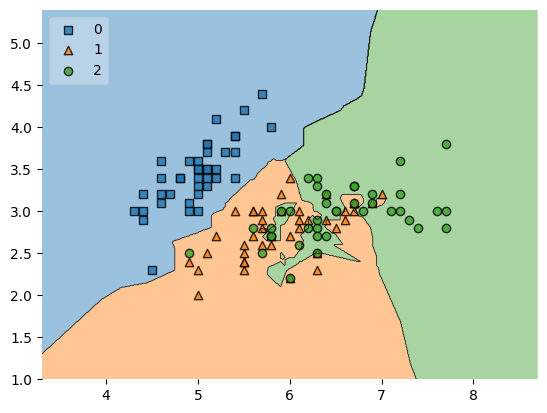

score=           0.8
precision score= 0.8047138047138046
cross_val_score= 0.7083333333333333
y_pred_test=	 [1 0 2 1 1 0 1 2 1 2 2 0 0 0 0 2 2 1 1 1 0 1 0 1 2 2 1 2 0 0]
y_test=     	 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
comparaison=	 [ True  True  True  True  True  True  True  True  True False  True  True
  True  True  True False  True  True  True False  True False  True False
  True  True False  True  True  True]
[[10  0  0]
 [ 0  7  2]
 [ 0  4  7]]


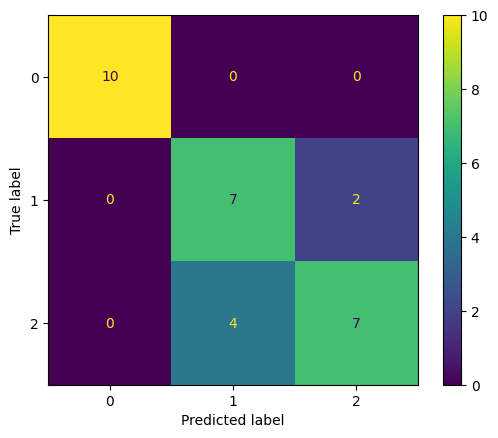

In [26]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# librairie uniquement destiné à dessiner KNN (à ne pas retenir !)
from mlxtend.plotting import plot_decision_regions

# ce dataset est une classification (classifier) qui permet
# predire si n attributs est dans cette étiquette (target)
# - class:
#    - Iris-Setosa
#    - Iris-Versicolour
#    - Iris-Virginica
iris_dataset = load_iris()

X = iris_dataset.data[:, 0:2]
y = iris_dataset.target

# méthode pour separer en 2 catégories, un pour
# l'apprentissage (train), l'autre pour la prediction (test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# ce modele est uniquement utile pour la classification
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train, y_train)

plot_decision_regions(X_train, y_train, clf=knn_classifier, legend=2)
plt.show()

# prediction de X_test (pour faire la comparaison avec y_test)
y_pred_test = knn_classifier.predict(X_test)

# La meilleure valeur est 1 et la pire est 0 pour tout les scores
print("score=          ", knn_classifier.score(X_test, y_test))
print("precision score=", precision_score(y_test, y_pred_test, average=None).mean())
print("cross_val_score=", cross_val_score(knn_classifier, X_train, y_train, cv=5,scoring="accuracy").mean())

# comparaison entre prediction et valeur réelle 
print("y_pred_test=\t", y_pred_test)
print("y_test=     \t", y_test)
print("comparaison=\t", y_test == y_pred_test)

# - class:
#    - Iris-Setosa
#    - Iris-Versicolour
#    - Iris-Virginica

# ligne: y_test, colonne: y_pred_test
# - si diagonale: prediction correcte
# - sinon un chiffre est hors-diagonle, 
#   erreur de classification
# 
# les lignes et colonnes sont les `classes` y 
# (Setosa, Versicolour, Virginica)  
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
# la matrice de confusion bien représenté (matplotlib)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_classifier.classes_).plot()
plt.show()

### Support Vector Classifier (SVC)

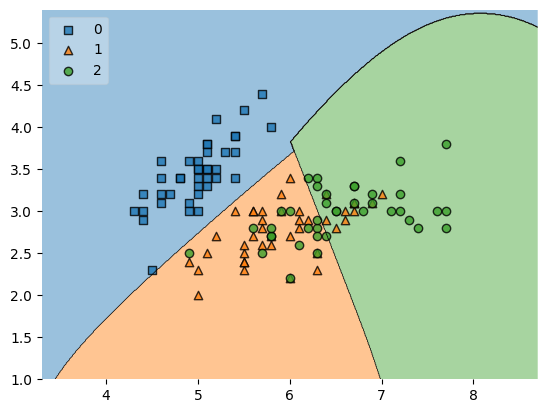

score=           0.9
precision score= 0.9027777777777778
cross_val_score= 0.7750000000000001
y_pred_test=	 [1 0 2 1 2 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 1 0 2 2 2 2 2 0 0]
y_test=     	 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
comparaison=	 [ True  True  True  True False  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True False  True  True
  True  True  True  True  True  True]
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]


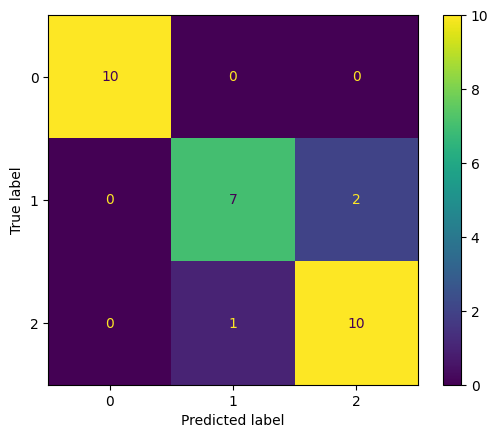

In [27]:
from sklearn.svm._classes import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
# librairie uniquement destiné à dessiner KNN (à ne pas retenir !)
from mlxtend.plotting import plot_decision_regions

iris_dataset = load_iris()

X = iris_dataset.data[:, 0:2]
y = iris_dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svc: SVC = SVC()
svc.fit(X_train, y_train)

plot_decision_regions(X_train, y_train, clf=svc, legend=2)
plt.show()

# prediction de X_test (pour faire la comparaison avec y_test)
y_pred_test = svc.predict(X_test)

# La meilleure valeur est 1 et la pire est 0 pour tout les scores
print("score=          ", svc.score(X_test, y_test))
print("precision score=", precision_score(y_test, y_pred_test, average=None).mean())
print("cross_val_score=", cross_val_score(svc, X_train, y_train, cv=5,scoring="accuracy").mean())

# comparaison entre prediction et valeur réelle 
print("y_pred_test=\t", y_pred_test)
print("y_test=     \t", y_test)
print("comparaison=\t", y_test == y_pred_test)

# - class:
#    - Iris-Setosa
#    - Iris-Versicolour
#    - Iris-Virginica

# ligne: y_test, colonne: y_pred_test
# - si diagonale: prediction correcte
# - sinon un chiffre est hors-diagonle, 
#   erreur de classification
# 
# les lignes et colonnes sont les `classes` y 
# (Setosa, Versicolour, Virginica)  
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
# la matrice de confusion bien représenté (matplotlib)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svc.classes_).plot()
plt.show()

### Arbres de Décision (DTC)

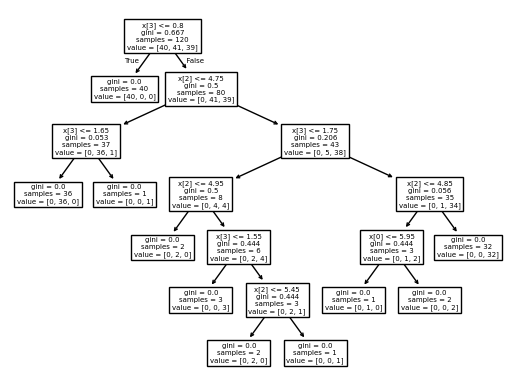

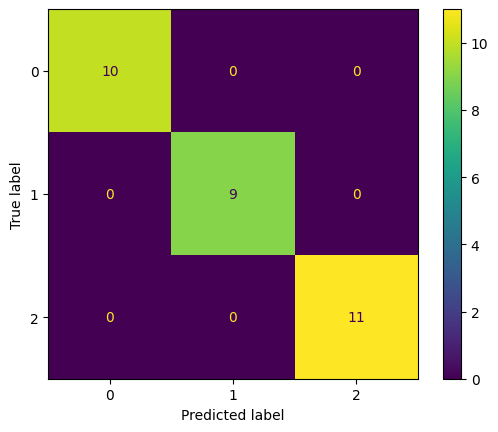

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

iris_dataset = load_iris()

X = iris_dataset.data
y = iris_dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
plot_tree(dtc)

y_pred_test = dtc.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
# la matrice de confusion bien représenté (matplotlib)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtc.classes_).plot()
plt.show()

## Prétraitement et Pipelines

### Normalisation vs Standardisation

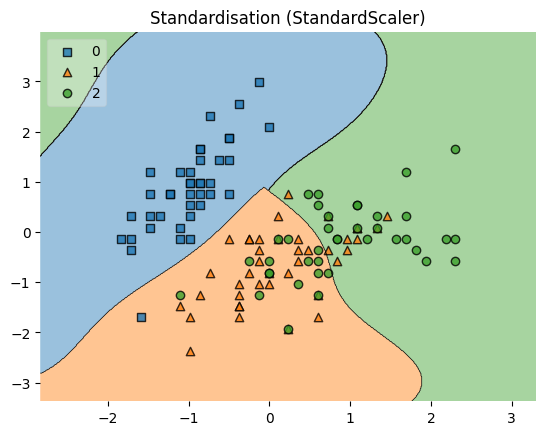

score Standardisation (StandardScaler)=           0.8333333333333334
precision scoreStandardisation (StandardScaler)= 0.8333333333333334
cross_val_scoreStandardisation (StandardScaler)= 0.7666666666666667
y_pred_test Standardisation (StandardScaler)=	 [1 0 2 1 2 0 1 2 1 1 2 0 0 0 0 2 2 1 1 1 0 1 0 1 2 2 2 2 0 0]
y_test Standardisation (StandardScaler)=     	 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
comparaison Standardisation (StandardScaler)=	 [ True  True  True  True False  True  True  True  True  True  True  True
  True  True  True False  True  True  True False  True False  True False
  True  True  True  True  True  True]


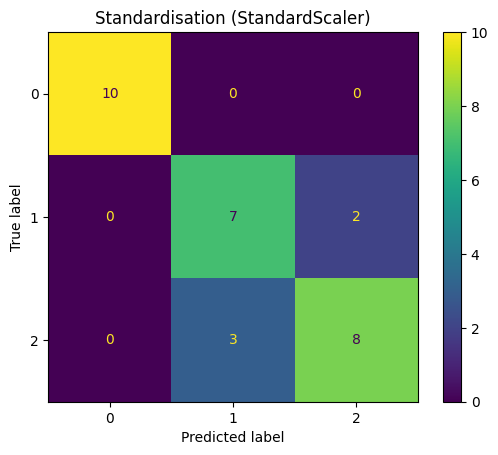

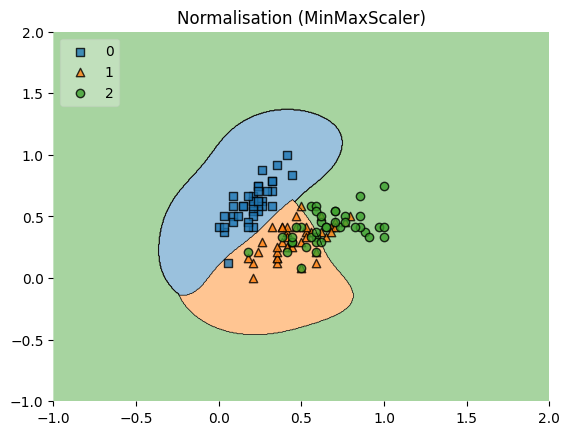

score Normalisation (MinMaxScaler)=           0.9
precision scoreNormalisation (MinMaxScaler)= 0.9027777777777778
cross_val_scoreNormalisation (MinMaxScaler)= 0.7666666666666667
y_pred_test Normalisation (MinMaxScaler)=	 [1 0 2 1 2 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 1 0 2 2 2 2 2 0 0]
y_test Normalisation (MinMaxScaler)=     	 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
comparaison Normalisation (MinMaxScaler)=	 [ True  True  True  True False  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True False  True  True
  True  True  True  True  True  True]


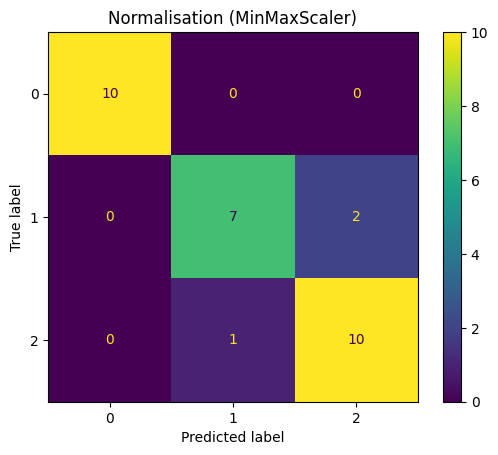

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
# librairie uniquement destiné à dessiner KNN (à ne pas retenir !)
from mlxtend.plotting import plot_decision_regions

iris_dataset = load_iris()

scalers = [
    ("Standardisation (StandardScaler)", StandardScaler()),
    ("Normalisation (MinMaxScaler)", MinMaxScaler()),
]

X = iris_dataset.data[:, 0:2]
y = iris_dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for name, scaler in scalers:
    # on peut aussi le faire avec make_pipeline
    # model = make_pipeline(SVC(), scaler)

    scaler.fit(X_train, y_train)
    # les features redimensionné
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = SVC()
    model.fit(X_train_scaled, y_train)


    plot_decision_regions(X_train_scaled, y_train, model, legend=2)
    plt.title(name)
    plt.show()

    # prediction de X_test (pour faire la comparaison avec y_test)
    y_pred_test = model.predict(X_test_scaled)

    # La meilleure valeur est 1 et la pire est 0 pour tout les scores
    print(f"score {name}=          ", model.score(X_test_scaled, y_test))
    print(f"precision score{name}=", precision_score(y_test, y_pred_test, average=None).mean())
    print(
        f"cross_val_score{name}=",
        cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy").mean(),
    )

    # comparaison entre prediction et valeur réelle
    print(f"y_pred_test {name}=\t", y_pred_test)
    print(f"y_test {name}=     \t", y_test)
    print(f"comparaison {name}=\t", y_test == y_pred_test)

    cm = confusion_matrix(y_test, y_pred_test)
    # la matrice de confusion bien représenté (matplotlib)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()
    plt.title(name)
    plt.show()

## Modèles de Régression

### k-NN Regressor

In [30]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

diabetes_dataset = load_diabetes()

X = diabetes_dataset.data
y = diabetes_dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn_regressor = KNeighborsRegressor(n_neighbors=3)
knn_regressor.fit(X_train, y_train)

y_pred_test = knn_regressor.predict(X_test)

print(knn_regressor.score(X_test, y_test))
print(mean_squared_error(y_test, y_pred_test))

0.36498737331014663
3364.3932584269664


### K-Means

performance:  4.766012421511284
labels:  [0 0 2 1 1 1]
coordonnée cluster: [[ 0.00877662  0.02057851  0.01610192  0.00162208  0.05149575  0.05822141
  -0.03535937  0.06327138  0.03499225  0.02491947]
 [-0.02774302 -0.00266508 -0.03238987 -0.03270817 -0.04472844 -0.03996904
   0.01064154 -0.03589806 -0.04001021 -0.0323145 ]
 [ 0.02250788  0.01177328  0.03720348  0.03726052 -0.00704469 -0.00986475
  -0.0252932   0.01280078  0.03127074  0.03083343]
 [ 0.00943075 -0.03374772 -0.01037863  0.00295294  0.0208001   0.00877174
   0.05224285 -0.02881842 -0.0133366  -0.01036785]]


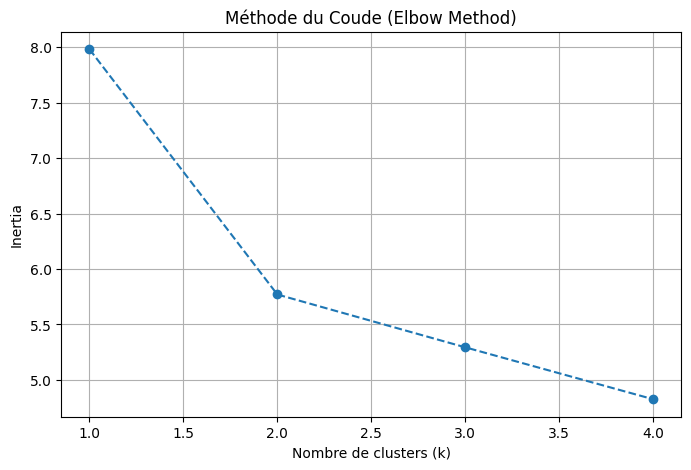

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

diabetes_dataset = load_diabetes()

X = diabetes_dataset.data
y = diabetes_dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = KMeans(n_clusters=4)
model.fit(X_train, y_train)

# - nertie élevée : Les points sont très dispersés 
# autour des centres. Les clusters sont mal définis 
# ou trop grands.
# - Inertie faible : Les points sont très regroupés
# autour des centres. Les clusters sont denses.
# - Inertie = 0 : Cela arrive si tu as autant de 
# clusters que de points (chaque point est son propre 
# centre). Ce n'est pas un bon modèle, c'est de 
# l'overfitting.
print("performance: ", model.inertia_)
print("labels: ", model.labels_[0:6])
# coordonnées du centre des points (10 attributs == 10 dimension)
print("coordonnée cluster:", model.cluster_centers_)

# Elbow (prend la valeur se situant approximativement au coude)
inertias = []
range = np.arange(1, 5)
for k in range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_train, y_train)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range, inertias, marker='o', linestyle='--')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertia')
plt.title('Méthode du Coude (Elbow Method)')
plt.grid(True)
plt.show()

## Apprentissage non-supervisée

performance:  5.9880493207489005
labels:  [0 2 0 1 1 2]
coordonnée cluster: [[ 0.01842861  0.05068012  0.00209788  0.01242191 -0.01918116 -0.00828483
  -0.0248646   0.00723306 -0.00028262  0.00738661]
 [ 0.00774035 -0.04464164  0.02592202  0.01967482  0.01017055  0.00546712
   0.00585085 -0.00481418  0.0132721   0.00971822]
 [-0.03033267 -0.02597724 -0.03554053 -0.03669653 -0.02847221 -0.03143307
   0.03429973 -0.04078363 -0.0407951  -0.03438835]
 [ 0.01656321  0.02314272  0.02671522  0.02188501  0.05912585  0.05481972
  -0.02883792  0.06058656  0.05131803  0.03505068]]


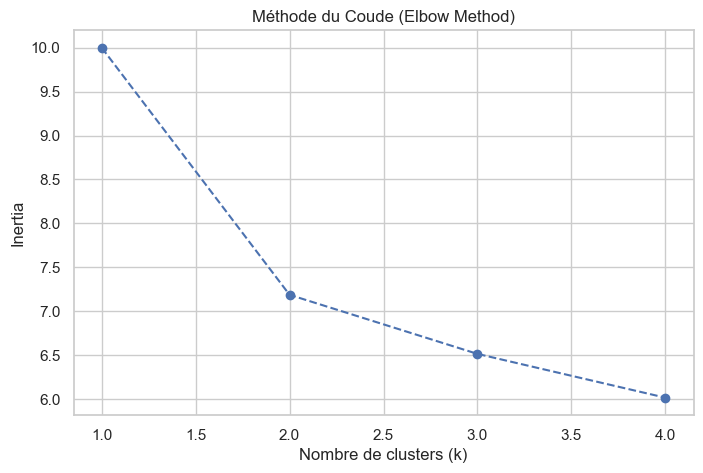

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_diabetes

# K-Means est un model se basant sur le clustering qui est
# la principale méthode utilisé pour l'apprentissage non superpisé.
# qui est un apprentissage sans étiquette (target) 

diabetes_dataset = load_diabetes()

X = diabetes_dataset.data 

model = KMeans(n_clusters=4)
model.fit(X)

print("performance: ", model.inertia_)
print("labels: ", model.labels_[0:6])

print("coordonnée cluster:", model.cluster_centers_)

# Elbow
inertias = []
range = np.arange(1, 5)
for k in range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range, inertias, marker='o', linestyle='--')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertia')
plt.title('Méthode du Coude (Elbow Method)')
plt.grid(True)
plt.show()

### Linear Regression

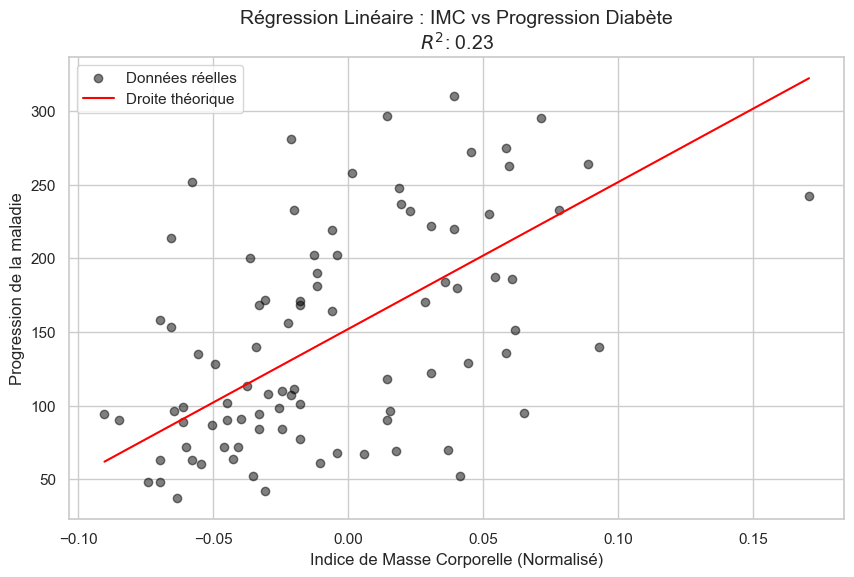

Coefficient (w): 998.58
Intercept (b): 152.00


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
X = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

regr = LinearRegression()
regr.fit(X_train, y_train)

y_pred = regr.predict(X_test)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, color="black", alpha=0.5, label="Données réelles")

# coordonnée x
x_axe = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
# coordonnée y
y_courbe = regr.coef_[0] * x_axe + regr.intercept_
# droite crée par l'algorithme
plt.plot(x_axe, y_courbe, color='red', label='Droite théorique')

plt.title(
    f"Régression Linéaire : IMC vs Progression Diabète\n$R^2$: {r2_score(y_test, y_pred):.2f}",
    fontsize=14,
)
plt.xlabel("Indice de Masse Corporelle (Normalisé)")
plt.ylabel("Progression de la maladie")
plt.legend()
plt.show()

print(f"Coefficient (w): {regr.coef_[0]:.2f}")
print(f"Intercept (b): {regr.intercept_:.2f}")

## PCA

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

# PCA permet de limité le nombre d'attribut utilisé lors de 
# l'apprentissage, elle recupère automatiquement les attributs
# avec la plus grande variance 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# La variance permet de déterminer l'impact 
# qu'as un attribut sur la prédiction 
variance = pca.explained_variance_ratio_.sum()
print(f"Information conservée : {variance:.2%}")

# Plus la variance est grande plus elle aura un impact
# sur la prédiction à l'inverse plus elle est faible 
# moins elle aura d'impact
print(pca.explained_variance_ratio_)

Information conservée : 55.17%
[0.40242108 0.14923197]
